In [7]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [10]:
df = pd.read_csv('top100cities_weather_data.csv')
df

,City,Temperature (Celsius),Wind Speed (m/s),Latitude,Longitude,Description,Country
0,Paris,10.46,2.06,48.8534,2.3488,clear sky,France
1,Dubai,29.32,3.09,25.2582,55.3047,clear sky,United Arab Emirates
2,Madrid,9.97,3.60,40.4165,-3.7026,clear sky,Spain
3,Tokyo,21.58,2.06,35.6895,139.6917,broken clouds,Japan
4,Amsterdam,8.00,3.58,52.3740,4.8897,clear sky,Netherlands
...,...,...,...,...,...,...,...
95,Punta Cana,26.87,6.69,18.5818,-68.4043,few clouds,Dominican Republic
96,Guilin,24.06,0.97,25.2819,110.2864,clear sky,China
97,Hanoi,28.00,2.49,21.0245,105.8412,clear sky,Vietnam
98,Cairo,19.42,4.63,30.0626,31.2497,clear sky,Egypt


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   100 non-null    object 
 1   Temperature (Celsius)  100 non-null    float64
 2   Wind Speed (m/s)       100 non-null    float64
 3   Latitude               100 non-null    float64
 4   Longitude              100 non-null    float64
 5   Description            100 non-null    object 
 6   Country                100 non-null    object 
dtypes: float64(4), object(3)
memory usage: 5.6+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Temperature (Celsius),Wind Speed (m/s),Latitude,Longitude
count,100.000000,100.00000,100.000000,100.000000
mean,18.861700,3.59920,31.249418,18.550782
std,7.017078,2.66491,19.451234,75.876596
min,5.290000,0.45000,-34.613200,-157.858300
25%,13.825000,1.54000,23.489600,-8.741575
50%,18.005000,2.92500,35.173650,18.552400
75%,26.120000,4.63000,43.825025,74.154525
max,32.350000,14.75000,59.437000,151.207300


In [11]:
df = df.drop(columns = ['Country'])

values are realistic

In [12]:
df.Description.unique()

<StringArray>
[           'clear sky',        'broken clouds',          'shower rain',
     'scattered clouds',      'overcast clouds',           'light rain',
           'few clouds',                 'mist',        'moderate rain',
 'heavy intensity rain',                  'fog',                 'haze',
                'smoke']
Length: 13, dtype: str

In [13]:
X = df.drop(columns = ['City'])

In [14]:
encoder = OneHotEncoder(sparse_output=False)
X_enc = encoder.fit_transform(X[['Description']])

In [15]:
sc = StandardScaler()
x_sc = sc.fit_transform(X.drop(columns = ['Description']))

In [16]:
X = np.hstack([X_enc, x_sc])

In [17]:
linked = linkage(X, method = 'ward')

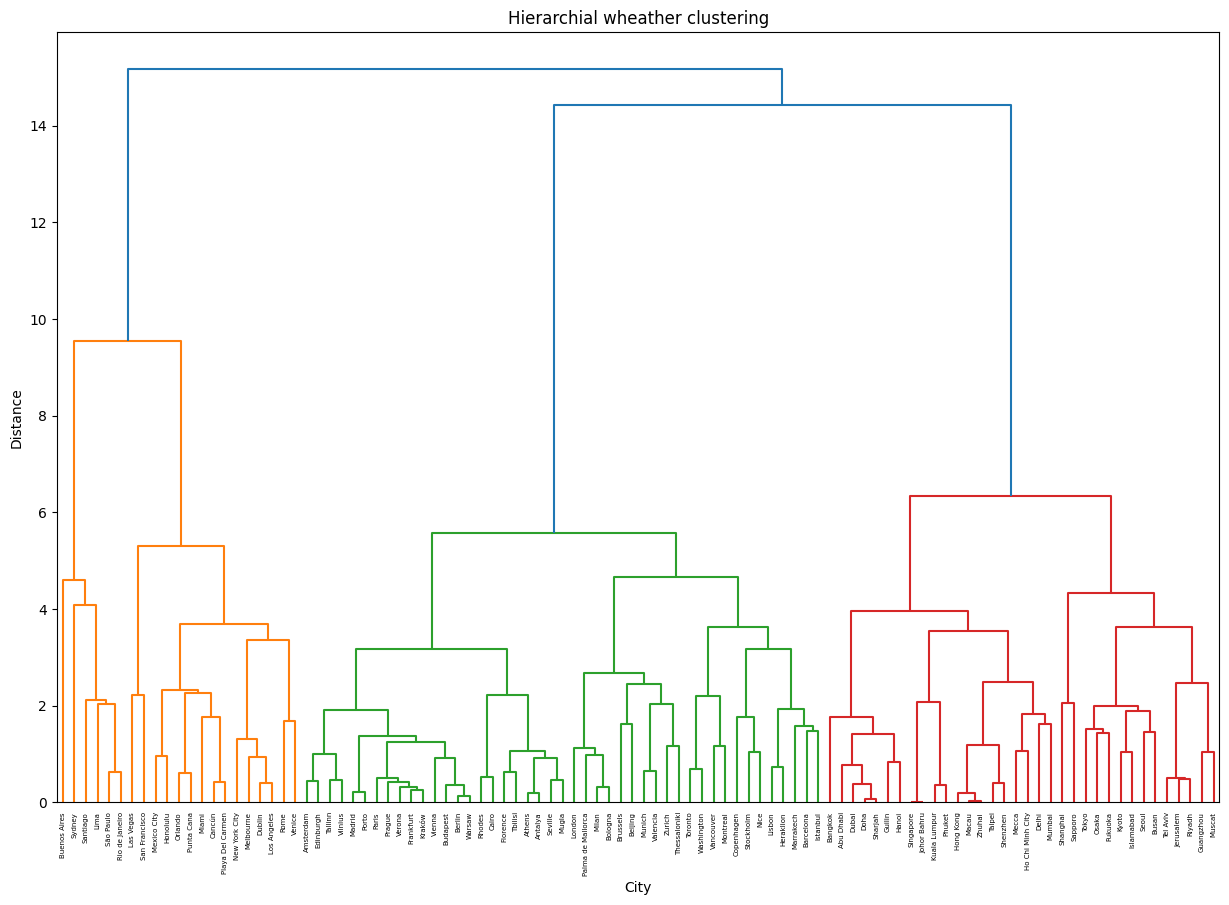

In [36]:
plt.figure(figsize=(15, 10))  

dendrogram(linked, orientation='top', labels=df['City'].values)
plt.title('Hierarchial wheather clustering')
plt.xlabel('City')
plt.ylabel('Distance')
plt.show()

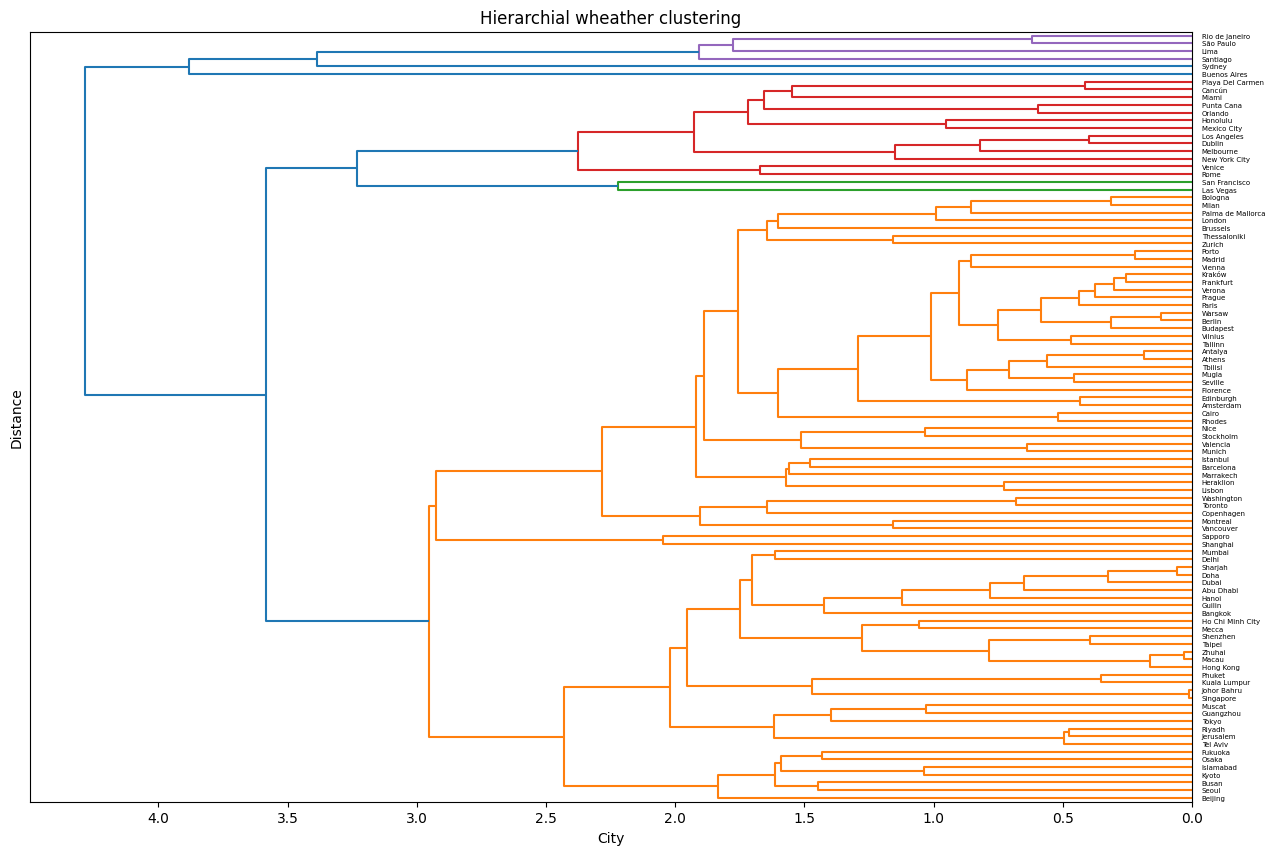

In [24]:
plt.figure(figsize=(15, 10))  

dendrogram(linkage(X, method='average', metric='euclidean'), orientation='left', labels=df['City'].values)
plt.title('Hierarchial wheather clustering')
plt.xlabel('City')
plt.ylabel('Distance')
plt.show()

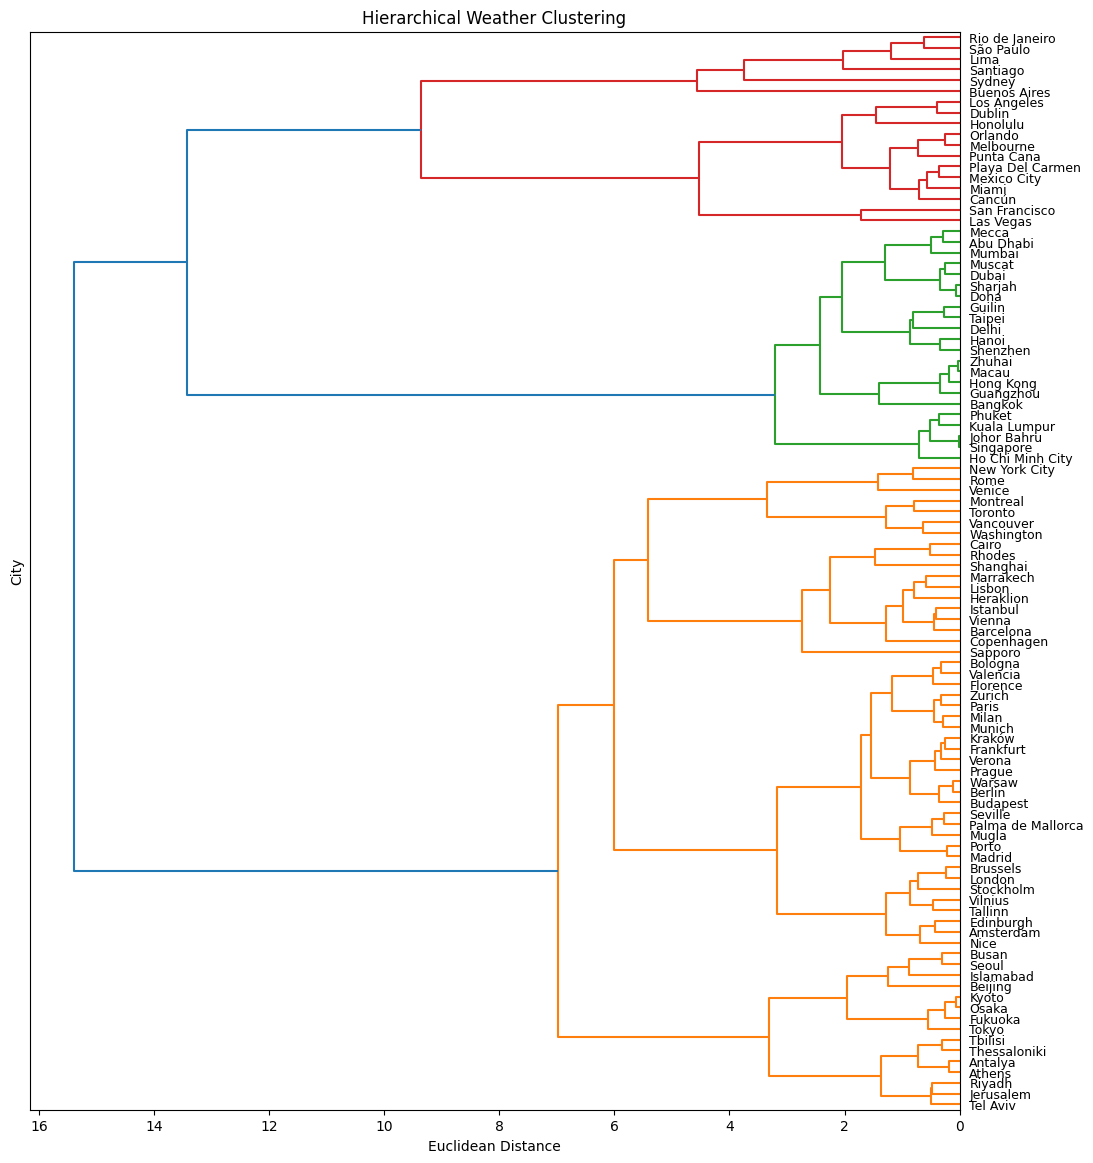

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(12, 14))
dendrogram(linkage(x_sc, method = 'ward'), orientation='left', labels=df['City'].values)
plt.title('Hierarchical Weather Clustering')
plt.xlabel('Euclidean Distance')
plt.ylabel('City')
plt.yticks(fontsize=9)
plt.savefig('dendo.png', dpi=400, bbox_inches='tight') 
plt.show()


plt.savefig('dendo.png', dpi=400, bbox_inches='tight') 

## Numeric only

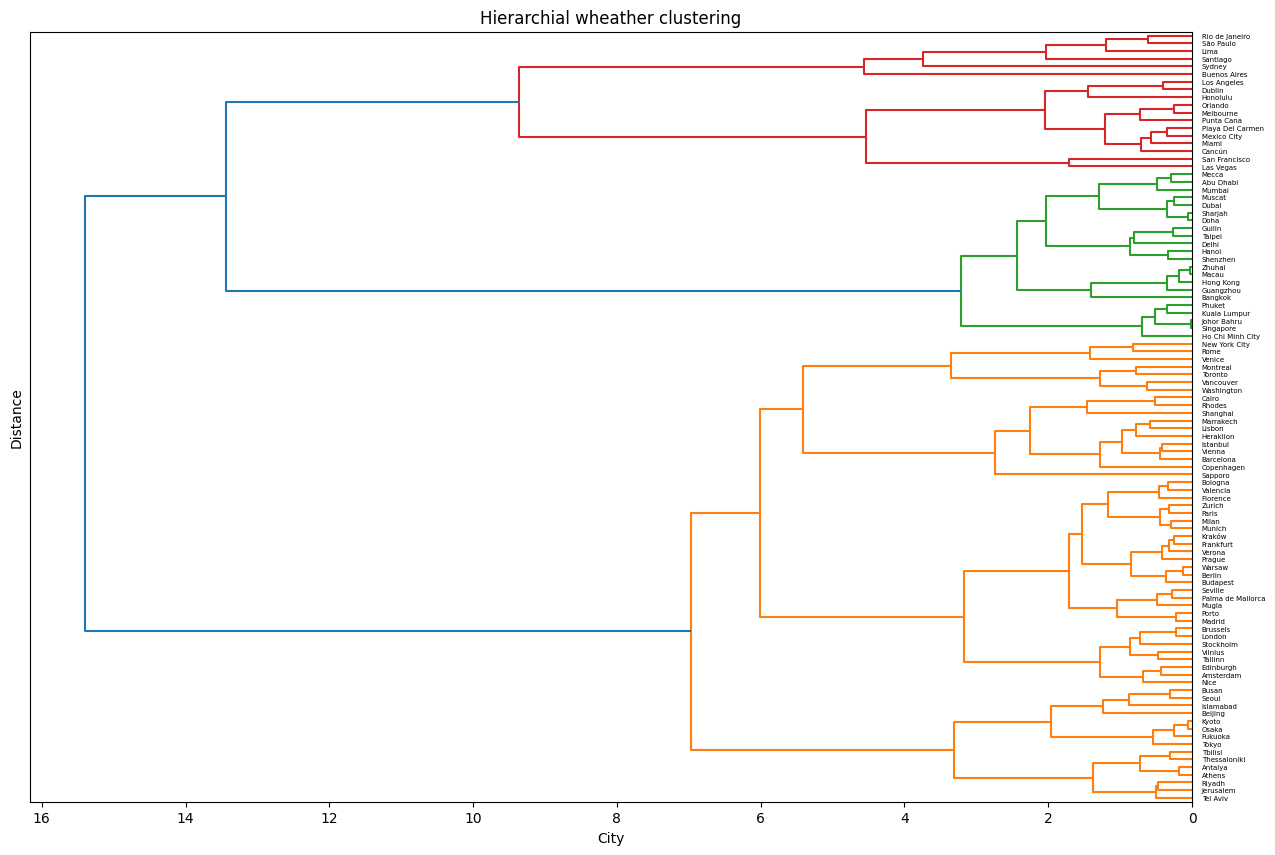

In [23]:
temp_data = df.select_dtypes(include=['number'])

X_sc = sc.fit_transform(temp_data)

plt.figure(figsize=(15, 10))  
dendrogram(linkage(X_sc, method = 'ward'), orientation='left', labels=df['City'].values)
plt.title('Hierarchial wheather clustering')
plt.xlabel('City')
plt.ylabel('Distance')
plt.show()